XGBOOST CLASSIFIER - PNEUMONIA DETECTION

📂 Loading dataset...
✅ Loaded: 4102 rows × 203 columns

📋 First 5 rows:
                   Image_Name  Label      Class  Feature_1  Feature_2  \
0  BACTERIA-5132924-0001.jpeg      1  Pneumonia -11.545157 -13.717647   
1  BACTERIA-1777631-0001.jpeg      1  Pneumonia  20.818638   8.152621   
2  BACTERIA-7392124-0001.jpeg      1  Pneumonia  30.078508   9.970522   
3  BACTERIA-9072988-0007.jpeg      1  Pneumonia -19.790420  16.773912   
4  BACTERIA-7560163-0001.jpeg      1  Pneumonia -26.874071 -19.328613   

   Feature_3  Feature_4  Feature_5  Feature_6  Feature_7  ...  Feature_191  \
0   2.459949  14.375765  19.150570  -8.340388   6.690397  ...    -2.288996   
1  -1.169066  15.593989   2.154690  18.117068 -13.609882  ...    -2.427195   
2  33.507303 -23.685114  -2.529166  -7.976503 -12.485124  ...    -3.986868   
3  12.641352  25.069962  -2.071930   3.694015   5.166889  ...     0.148843   
4   0.139244  19.195918   3.973868  -8.645415 -20.761864 

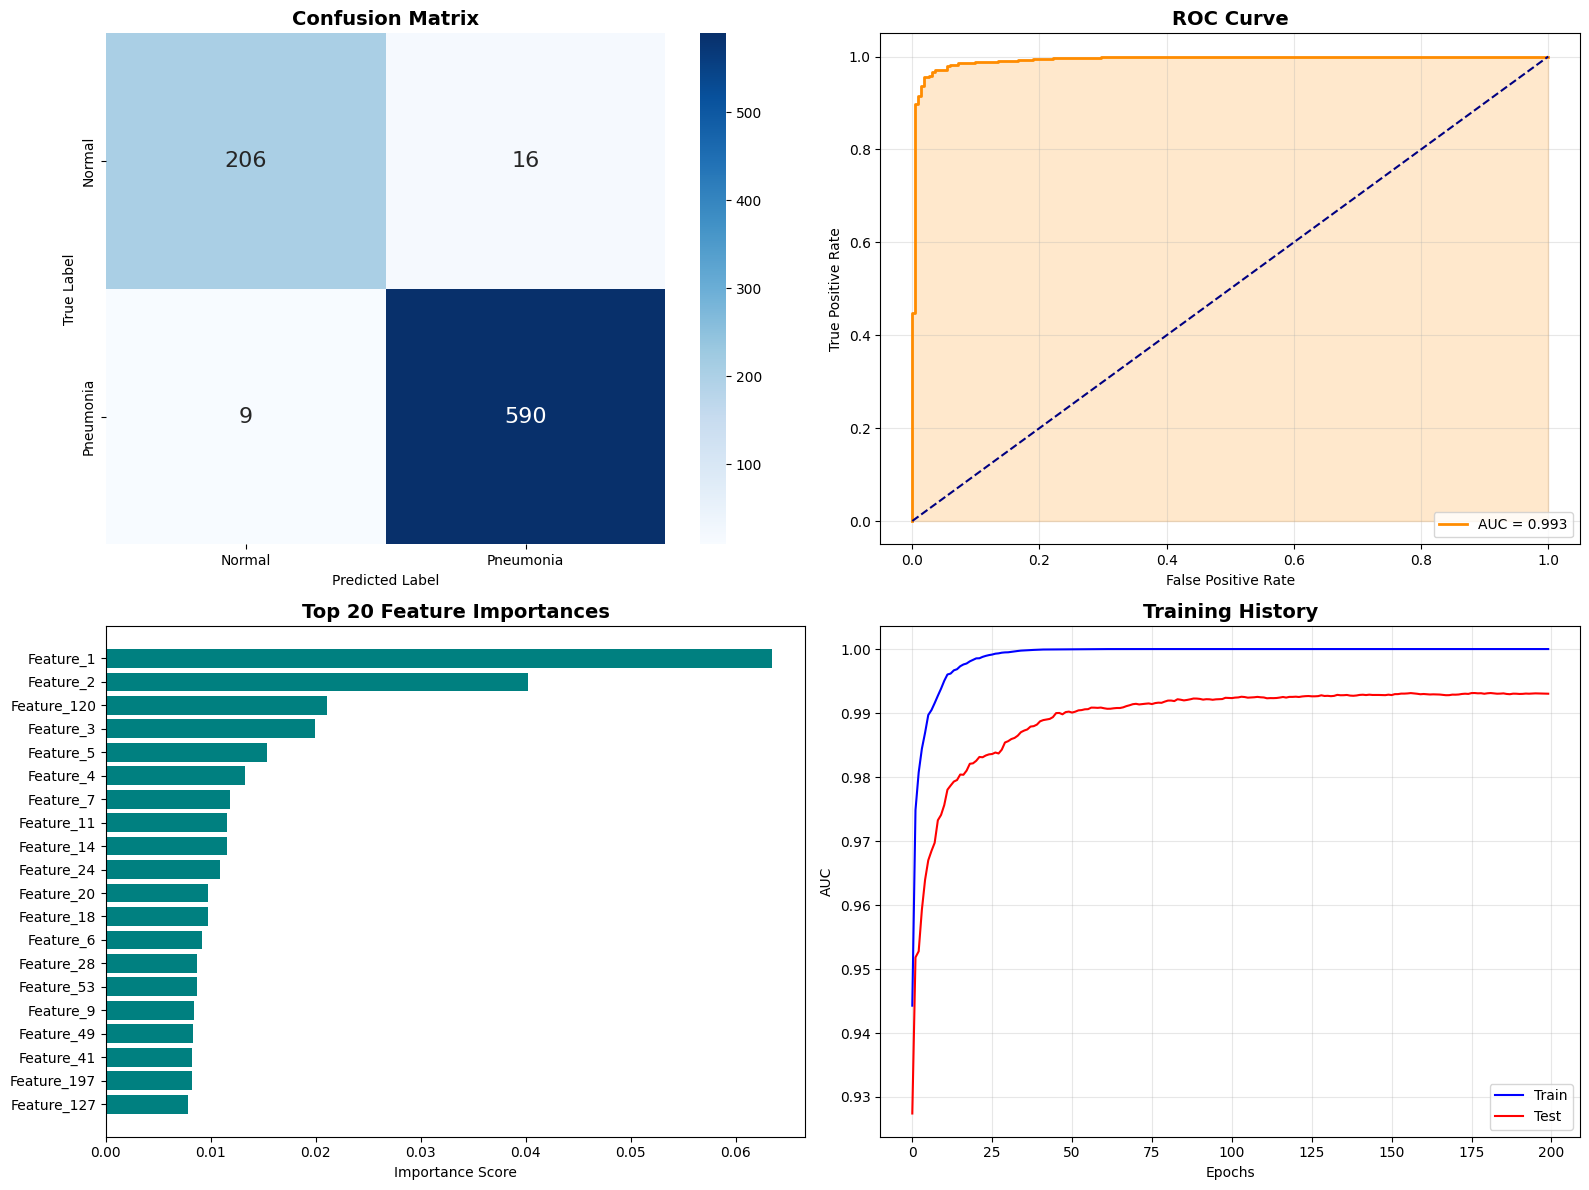


MODEL SUMMARY

🔧 XGBoost Parameters:
   Trees:        200
   Max Depth:    6
   Learning Rate:0.1
   Subsample:    0.8
   Colsample:    0.8

📈 Final Test Performance:
   Accuracy:   0.9695 (97.0%)
   Precision:  0.9736 (97.4%)
   Recall:     0.9850 (98.5%)
   F1-Score:   0.9793 (97.9%)
   AUC-ROC:    0.9930 (99.3%)

📊 Top 5 Important Features:
   Feature_1: 0.0635
   Feature_2: 0.0402
   Feature_120: 0.0211
   Feature_3: 0.0199
   Feature_5: 0.0154

✅ XGBOOST CLASSIFICATION COMPLETE!


In [1]:
# ============================================
# XGBOOST CLASSIFIER - PNEUMONIA DETECTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, roc_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("XGBOOST CLASSIFIER - PNEUMONIA DETECTION")
print("="*60)

# ============================================
# 1. LOAD THE CSV DATASET
# ============================================

csv_path = '/kaggle/input/datasets/mtishakil/chest-x-ray-feature-extracted-dataset-for-ml/Chest X-Ray Feature Extracted Dataset for ML.csv'

print(f"\n📂 Loading dataset...")
df = pd.read_csv(csv_path)
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📊 Class Distribution:")
print(df['Class'].value_counts())
print(f"   Normal:     {len(df[df['Label']==0])}")
print(f"   Pneumonia:  {len(df[df['Label']==1])}")

# ============================================
# 2. PREPARE FEATURES AND TARGET
# ============================================

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

X = df.drop(['Image_Name', 'Label', 'Class'], axis=1)
y = df['Label']

print(f"\n✅ Features: {X.shape[1]} columns")
print(f"✅ Target: {len(y)} samples")

# ============================================
# 3. TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n✅ Training: {len(X_train)} samples")
print(f"   Normal: {np.sum(y_train==0)}, Pneumonia: {np.sum(y_train==1)}")
print(f"✅ Testing:  {len(X_test)} samples")
print(f"   Normal: {np.sum(y_test==0)}, Pneumonia: {np.sum(y_test==1)}")

# Calculate scale_pos_weight for imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"\n⚖️  scale_pos_weight: {scale_pos_weight:.3f}")

# ============================================
# 4. TRAIN XGBOOST
# ============================================

print("\n" + "="*60)
print("TRAINING XGBOOST")
print("="*60)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,          # Number of trees
    max_depth=6,               # Maximum tree depth
    learning_rate=0.1,         # Step size
    subsample=0.8,             # Row sampling
    colsample_bytree=0.8,      # Column sampling per tree
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

print("⏳ Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)
print("✅ Training complete!")

# ============================================
# 5. EVALUATE
# ============================================

print("\n" + "="*60)
print("RESULTS")
print("="*60)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:, 1])

print(f"\n📊 Test Performance:")
print(f"   Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:   {f1:.4f} ({f1*100:.1f}%)")
print(f"   AUC-ROC:    {auc:.4f} ({auc*100:.1f}%)")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

# ============================================
# 6. CONFUSION MATRIX & MEDICAL METRICS
# ============================================

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n🏥 Medical Metrics:")
print(f"   Correct Normal:     {tn}")
print(f"   False Alarms:       {fp}")
print(f"   Missed Pneumonia:   {fn} {'⚠️' if fn>0 else '✅'}")
print(f"   Caught Pneumonia:   {tp}")
print(f"   Sensitivity:        {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.1f}%)")
print(f"   Specificity:        {tn/(tn+fp):.4f} ({tn/(tn+fp)*100:.1f}%)")
print(f"   PPV (Precision):    {tp/(tp+fp):.4f} ({tp/(tp+fp)*100:.1f}%)")
print(f"   NPV:                {tn/(tn+fn):.4f} ({tn/(tn+fn)*100:.1f}%)")

# ============================================
# 7. VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={'size': 16})
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.3f}')
axes[0, 1].plot([0, 1], [0, 1], '--', color='navy')
axes[0, 1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

axes[1, 0].barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='teal')
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_title('Top 20 Feature Importances', fontsize=14, fontweight='bold')

# Training History
results = xgb_model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

axes[1, 1].plot(x_axis, results['validation_0']['auc'], label='Train', color='blue')
axes[1, 1].plot(x_axis, results['validation_1']['auc'], label='Test', color='red')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_title('Training History', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. MODEL SUMMARY
# ============================================

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)

print(f"\n🔧 XGBoost Parameters:")
print(f"   Trees:        {xgb_model.n_estimators}")
print(f"   Max Depth:    {xgb_model.max_depth}")
print(f"   Learning Rate:{xgb_model.learning_rate}")
print(f"   Subsample:    {xgb_model.subsample}")
print(f"   Colsample:    {xgb_model.colsample_bytree}")

print(f"\n📈 Final Test Performance:")
print(f"   Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:   {f1:.4f} ({f1*100:.1f}%)")
print(f"   AUC-ROC:    {auc:.4f} ({auc*100:.1f}%)")

print(f"\n📊 Top 5 Important Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "="*60)
print("✅ XGBOOST CLASSIFICATION COMPLETE!")
print("="*60)